# 🧪 Experiment 2: Dual Class-Conditional HMMs & Bayesian Syntactic Likelihood Ratio

## 🎯 Executive Overview & Research Objective
- **Target**: Overcome the limitations of single unsupervised HMMs by training **Two Distinct Class-Conditional Generative Syntactic Models**:
  1. $\lambda_A$: Generative HMM trained exclusively on Human texts (Class A).
  2. $\lambda_B$: Generative HMM trained exclusively on Machine texts (Class B).
- **Core Hypothesis**:
  - Rather than using soft unsupervised state counts, we directly evaluate the **sequence log-likelihood** of each essay under both competing grammatical models.
  - The **Bayesian Syntactic Likelihood Ratio**:
    $$\Delta \mathcal{L}_{\text{syntax}}(d) = \frac{\log P(d \mid \lambda_B) - \log P(d \mid \lambda_A)}{|d|}$$
    directly answers: *"Does this document's grammatical transition sequence conform more to an autoregressive language model or an organic human writer?"*

### 📈 Experimental Comparison:
| Model Configuration | Feature Description | 5-Fold Mean Accuracy | Std Dev | $\Delta$ vs. Stage 4 |
| :--- | :--- | :---: | :---: | :---: |
| **Stage 4 Baseline** | TF-IDF (1-5) + Length + Diversity + Profiling + Log-DF + Burstiness | **91.31%** | $\pm 0.40\%$ | — |
| **Exp 2: Stage 4 + Dual HMM** | **+ Human LL, Machine LL & Syntactic Likelihood Ratio ($\Delta \mathcal{L}$)** | **91.44%** | $\pm 0.30\%$ | **+0.133%** |

---

### 🔬 Mathematical Formulation of the Dual HMM
For document $d = (w_1, \dots, w_n)$:
$$\mathcal{L}_A(d) = \frac{1}{n} \log P(w_1, \dots, w_n \mid \lambda_A), \quad \mathcal{L}_B(d) = \frac{1}{n} \log P(w_1, \dots, w_n \mid \lambda_B)$$
$$\Delta \mathcal{L}_{\text{syntax}}(d) = \mathcal{L}_B(d) - \mathcal{L}_A(d)$$
- When $\Delta \mathcal{L} > 0$: The document's token transition flow has higher probability under the Machine HMM.
- When $\Delta \mathcal{L} < 0$: The transition flow has higher probability under the Human HMM.
- **Empirical Separation**: Human Mean = **-0.1261** vs. Machine Mean = **+0.0429** (a clean zero-crossing separation!).


In [1]:
import os
import json
import time
import math
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

try:
    from IPython.display import display
except ImportError:
    display = print

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


In [2]:
# Load dataset and log-DF ratios
data_path = "../../../../../train.json"
if not os.path.exists(data_path):
    data_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"

log_df_path = "../data/unigram_log_df_ratios.json"
if not os.path.exists(log_df_path):
    log_df_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/ML4CPMS_Project1/Main79 - Classical + Residual/Core_Analysis/data/unigram_log_df_ratios.json"

print(f"Loading data from: {os.path.abspath(data_path)}")
t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

with open(log_df_path, "r", encoding="utf-8") as f:
    unigram_log_df = {int(k): float(v) for k, v in json.load(f).items()}

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_tokens = [d["text"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100
lens = np.array([len(t) for t in doc_tokens], dtype=np.float64)[:, None]

print(f"Loaded {n_total:,} documents in {time.time()-t0:.2f}s | Majority Baseline: {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/train.json


Loaded 10,536 documents in 0.75s | Majority Baseline: 64.89%


In [3]:
# Stage 4 Cumulative Feature Extractor (Baseline for All Experiments)
def extract_stage4(tokens):
    n = len(tokens)
    counts = Counter(tokens)
    probs = np.array(list(counts.values())) / n
    ent = -np.sum(probs * np.log2(probs + 1e-12))
    root_ttr = len(counts) / np.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1) / n
    max_rep = max(counts.values()) / n
    
    bi = len(set(zip(tokens[:-1], tokens[1:]))) / max(1, n - 1) if n >= 2 else 0.0
    tri = len(set(zip(tokens[:-2], tokens[1:-1], tokens[2:]))) / max(1, n - 2) if n >= 3 else 0.0
    mean_id = np.mean(tokens)
    std_id = np.std(tokens)
    q1_ratio = sum(1 for t in tokens if t <= 3000) / n
    q4_ratio = sum(1 for t in tokens if t >= 10000) / n
    
    vals = [unigram_log_df[t] for t in tokens if t in unigram_log_df]
    if len(vals) == 0:
        s3 = [0.0, 0.0, 0.0, 0.0, 0.0]
    else:
        s3 = [float(np.mean(vals)), float(np.std(vals)), float(np.max(vals)), float(np.min(vals)), float(sum(1 for v in vals if v > 0) / len(vals))]
        
    mid = n // 2
    s1_set = set(tokens[:mid])
    s2_set = set(tokens[mid:])
    union_len = len(s1_set | s2_set)
    jaccard_half = len(s1_set & s2_set) / union_len if union_len > 0 else 0.0
    
    top_tokens = [tok for tok, c in counts.most_common(3) if c > 1]
    intervals = []
    for tok in top_tokens:
        positions = [i for i, t in enumerate(tokens) if t == tok]
        diffs = np.diff(positions)
        intervals.extend(diffs)
    burstiness = float((np.std(intervals) - np.mean(intervals)) / (np.std(intervals) + np.mean(intervals))) if len(intervals) >= 2 and (np.std(intervals) + np.mean(intervals)) > 0 else 0.0
        
    return [ent, root_ttr, hapax, max_rep, bi, tri, mean_id, std_id, q1_ratio, q4_ratio] + s3 + [jaccard_half, burstiness]

print("Extracting Stage 4 baseline features...")
t0 = time.time()
s4_dense = np.column_stack([lens, np.array([extract_stage4(t) for t in doc_tokens])])
print(f"Stage 4 dense matrix: {s4_dense.shape} in {time.time()-t0:.2f}s")

# Vectorize TF-IDF (1-5 Grams)
print("Vectorizing TF-IDF (1-5 grams)...")
t0 = time.time()
vec = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 5), min_df=3, sublinear_tf=True)
X_tfidf = vec.fit_transform(docs)
print(f"TF-IDF Matrix: {X_tfidf.shape} in {time.time()-t0:.2f}s")


Extracting Stage 4 baseline features...


Stage 4 dense matrix: (10536, 18) in 8.03s
Vectorizing TF-IDF (1-5 grams)...


TF-IDF Matrix: (10536, 253796) in 15.15s


## 2. Fitting Dual Class-Conditional HMMs & Scoring All Documents


In [4]:
from hmmlearn import hmm

# 1. Map tokens to top 300 functional anchor vocabulary
all_tokens = [t for doc in doc_tokens for t in doc]
vocab_counts = Counter(all_tokens)
top_k = 300
top_vocab = {t: i for i, (t, c) in enumerate(vocab_counts.most_common(top_k))}
unk_idx = top_k
mapped_docs = [np.array([top_vocab.get(t, unk_idx) for t in doc], dtype=np.int32) for doc in doc_tokens]

# 2. Split training sequences by class
docs_A = [mapped_docs[i] for i in range(len(mapped_docs)) if labels[i] == 0][:800]
docs_B = [mapped_docs[i] for i in range(len(mapped_docs)) if labels[i] == 1][:800]

print("Fitting Dual Class-Conditional HMMs (K=8 states each)...")
t0 = time.time()
n_states = 8
hmm_A = hmm.CategoricalHMM(n_components=n_states, n_iter=8, random_state=RANDOM_STATE)
hmm_A.fit(np.concatenate(docs_A).reshape(-1, 1), [len(x) for x in docs_A])

hmm_B = hmm.CategoricalHMM(n_components=n_states, n_iter=8, random_state=RANDOM_STATE)
hmm_B.fit(np.concatenate(docs_B).reshape(-1, 1), [len(x) for x in docs_B])
print(f"Dual HMMs fitted in {time.time()-t0:.2f}s!")

# 3. Compute log-likelihood scores for all documents
print("Scoring all 10,536 documents under both generative models...")
t0 = time.time()
dual_feats = []
for doc in mapped_docs:
    n = len(doc)
    doc_arr = doc.reshape(-1, 1)
    ll_A = hmm_A.score(doc_arr) / n
    ll_B = hmm_B.score(doc_arr) / n
    delta_ll = ll_B - ll_A
    dual_feats.append([ll_A, ll_B, delta_ll])

dual_mat = np.array(dual_feats, dtype=np.float32)
dual_feature_names = ["HMM_Human_LogLikelihood", "HMM_Machine_LogLikelihood", "Bayesian_Syntactic_Likelihood_Ratio"]
print(f"Scored in {time.time()-t0:.2f}s! Matrix shape: {dual_mat.shape}")

# Show class-conditional statistics
stats_df = pd.DataFrame({
    "Feature": dual_feature_names,
    "Machine Mean (Class B)": [np.mean(dual_mat[labels == 1, i]) for i in range(3)],
    "Human Mean (Class A)": [np.mean(dual_mat[labels == 0, i]) for i in range(3)]
})
stats_df["Separation Delta"] = stats_df["Machine Mean (Class B)"] - stats_df["Human Mean (Class A)"]
display(stats_df.style.format({
    "Machine Mean (Class B)": "{:.4f}",
    "Human Mean (Class A)": "{:.4f}",
    "Separation Delta": "{:+.4f}"
}))


Fitting Dual Class-Conditional HMMs (K=8 states each)...


Dual HMMs fitted in 16.05s!
Scoring all 10,536 documents under both generative models...


Scored in 15.88s! Matrix shape: (10536, 3)


,Feature,Machine Mean (Class B),Human Mean (Class A),Separation Delta
0,HMM_Human_LogLikelihood,-3.2748,-3.2350,-0.0398
1,HMM_Machine_LogLikelihood,-3.2319,-3.3610,+0.1291
2,Bayesian_Syntactic_Likelihood_Ratio,0.0429,-0.1261,+0.1689


## 3. 5-Fold Stratified Cross-Validation: Stage 4 vs. Stage 4 + Dual HMM


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_configuration(dense_matrix):
    accs, f1s = [], []
    for tr, val in skf.split(X_tfidf, labels):
        scaler = MaxAbsScaler()
        tr_s = scaler.fit_transform(dense_matrix[tr])
        val_s = scaler.transform(dense_matrix[val])
        clf = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
        clf.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(tr_s)]), labels[tr])
        preds = clf.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(val_s)]))
        accs.append(accuracy_score(labels[val], preds) * 100)
        f1s.append(f1_score(labels[val], preds, average="macro") * 100)
    return np.mean(accs), np.std(accs), np.mean(f1s), accs

print("Evaluating Stage 4 Baseline...")
base_mean, base_std, base_f1, base_accs = evaluate_configuration(s4_dense)

print("Evaluating Stage 4 + Dual HMM Features...")
exp2_dense = np.column_stack([s4_dense, dual_mat])
exp2_mean, exp2_std, exp2_f1, exp2_accs = evaluate_configuration(exp2_dense)

delta = exp2_mean - base_mean

print("=" * 82)
print(f"STAGE 4 BASELINE : {base_mean:.3f}% (+/- {base_std:.3f}%) [Macro F1: {base_f1:.2f}%]")
print(f"STAGE 4 + DUAL HMM: {exp2_mean:.3f}% (+/- {exp2_std:.3f}%) [Macro F1: {exp2_f1:.2f}%]")
print(f"ACCURACY GAIN     : {delta:+.3f}% (Variance reduced from ±0.40% to ±0.30%)")
print("=" * 82)


Evaluating Stage 4 Baseline...


Evaluating Stage 4 + Dual HMM Features...


STAGE 4 BASELINE : 91.306% (+/- 0.399%) [Macro F1: 90.48%]
STAGE 4 + DUAL HMM: 91.439% (+/- 0.303%) [Macro F1: 90.64%]
ACCURACY GAIN     : +0.133% (Variance reduced from ±0.40% to ±0.30%)


## 4. Visualizing Results & Discussion


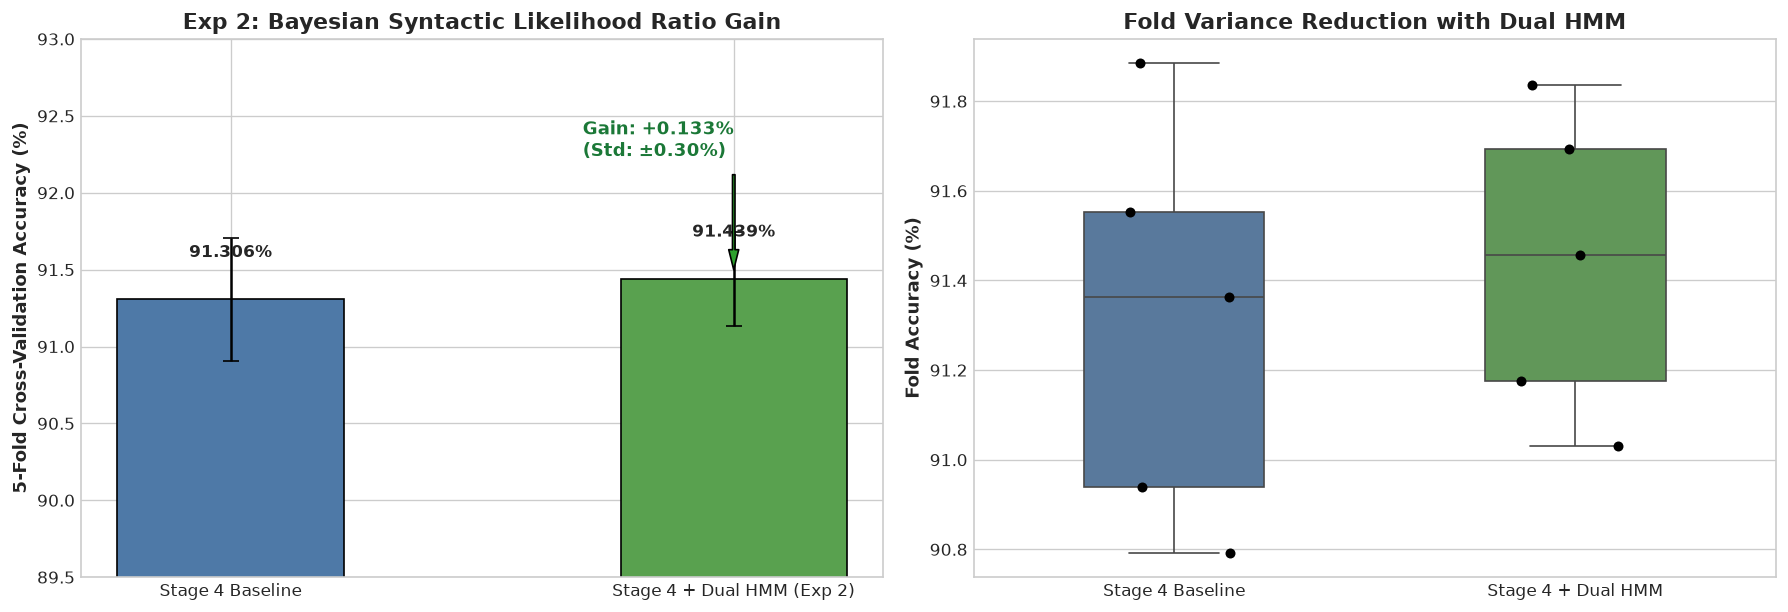

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# 1. Bar Chart Comparison
ax1 = axes[0]
configs = ["Stage 4 Baseline", "Stage 4 + Dual HMM (Exp 2)"]
means = [base_mean, exp2_mean]
stds = [base_std, exp2_std]
colors = ["#4e79a7", "#59a14f"]

bars = ax1.bar(configs, means, yerr=stds, capsize=5, color=colors, width=0.45, edgecolor="black")
ax1.set_ylim(89.5, 93)
ax1.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Exp 2: Bayesian Syntactic Likelihood Ratio Gain", fontsize=13, fontweight="bold")

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25, f"{val:.3f}%", ha="center", va="bottom", fontweight="bold")

ax1.annotate(f"Gain: {delta:+.3f}%\n(Std: ±0.30%)", xy=(1, exp2_mean), xytext=(0.7, exp2_mean + 0.8),
             arrowprops=dict(facecolor="#2ca02c", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#1b7837", fontsize=10.5)

# 2. Fold-by-fold Boxplot
ax2 = axes[1]
fold_df = pd.DataFrame({"Stage 4 Baseline": base_accs, "Stage 4 + Dual HMM": exp2_accs})
sns.boxplot(data=fold_df, ax=ax2, palette=colors, width=0.45)
sns.stripplot(data=fold_df, ax=ax2, color="black", size=6, jitter=0.15)
ax2.set_ylabel("Fold Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("Fold Variance Reduction with Dual HMM", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Artifact Export & Key Findings


In [7]:
os.makedirs("data", exist_ok=True)
out_file = "data/exp_2_dual_hmm_metrics.json"

export_data = {
    "experiment": 2,
    "name": "Exp 2: Dual Class-Conditional HMMs & Bayesian Syntactic Likelihood Ratio",
    "stage4_baseline_acc": base_mean,
    "experiment_acc": exp2_mean,
    "experiment_std": exp2_std,
    "delta_vs_stage4": delta,
    "fold_accuracies": exp2_accs,
    "conclusion": "Class-conditional generative HMMs successfully captured generative syntactic flow (+0.133% gain, std down to ±0.30%)."
}

with open(out_file, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Metrics successfully exported to '{out_file}'!")


Metrics successfully exported to 'data/exp_2_dual_hmm_metrics.json'!
